# Analisis Sentiment Livin By Mandiri Setelah Seruan Boikot

## 1.Scraping data dari Google Playstore

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.columns', None) # biar kolom tidak terpotong
pd.set_option('display.float.format','{:.2f}'.format) #scientific notation

In [227]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [228]:
pip install google_play_scraper

In [ ]:
from google_play_scraper import app

In [230]:
from google_play_scraper import Sort, reviews

In [231]:
from google_play_scraper import reviews, Sort
import pandas as pd

all_reviews = []
token = None

for i in range(13):  # 60 x 500 = 30.000
    result, token = reviews(
        'id.bmri.livin',
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=500,
        continuation_token=token
    )

    all_reviews.extend(result)

    print(f"Batch {i+1}: {len(result)} reviews | Total: {len(all_reviews)}")

    if token is None:
        print("Tidak ada data berikutnya.")
        break

df = pd.DataFrame(all_reviews)

Batch 1: 500 reviews | Total: 500
Batch 2: 500 reviews | Total: 1000
Batch 3: 500 reviews | Total: 1500
Batch 4: 500 reviews | Total: 2000
Batch 5: 500 reviews | Total: 2500
Batch 6: 500 reviews | Total: 3000
Batch 7: 500 reviews | Total: 3500
Batch 8: 500 reviews | Total: 4000
Batch 9: 500 reviews | Total: 4500
Batch 10: 500 reviews | Total: 5000
Batch 11: 500 reviews | Total: 5500
Batch 12: 500 reviews | Total: 6000
Batch 13: 500 reviews | Total: 6500


### Mengambil 6500 data terbaru

In [927]:
# import data ke CSV
import pandas as pd

df.to_csv("livin_reviews14.csv", index=False)

print("CSV berhasil dibuat!")
print(df.head(2))

CSV berhasil dibuat!
                               reviewId       userName  \
0  3d7bc146-31d0-498e-b685-f05c9d782e05  Umi Rahmawati   
1  0943f516-96d1-4697-b9cb-da13bf1e69b9  Hasban Nuzair   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8ocIgb7V6_1UgXd01umglGHsJP90968MkrcBgs_FDKIcThhJsCg=mo   
1  https://play-lh.googleusercontent.com/a/ACg8ocLTd_5XUuRFZaFDqXYw_moNSOtkjMXj2qzpRgpGoaKcO7A-1g=mo   

                                         content  score  thumbsUpCount  \
0                                        berguna      5              0   
1  one of the Best aplikasi for internet banking      5              0   

  reviewCreatedVersion                  at  \
0                3.7.0 2026-09-15 19:34:16   
1                3.7.0 2026-09-15 19:31:39   

                                                                                                                                 

In [234]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
# from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF
from nltk.tokenize import word_tokenize # tokenisasi
from nltk.corpus import stopwords # deteksi stopword
from nltk.stem import SnowballStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

## 2. Membaca dan memahami data

In [956]:

df = pd.read_csv('livin_reviews11.csv')
df.head(3)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3d7bc146-31d0-498e-b685-f05c9d782e05,Umi Rahmawati,https://play-lh.googleusercontent.com/a/ACg8ocIgb7V6_1UgXd01umglGHsJP90968MkrcBgs_FDKIcThhJsCg=mo,berguna,5,0,3.7.0,2026-09-15 19:34:16,"Halo Sahabat @Umi Rahmawati, terima kasih atas review yang telah Sahabat berikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' Call by Mandiri Bebas Pulsa melalui aplikasi Livin’ by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Romi",2026-09-15 19:37:51,3.7.0
1,0943f516-96d1-4697-b9cb-da13bf1e69b9,Hasban Nuzair,https://play-lh.googleusercontent.com/a/ACg8ocLTd_5XUuRFZaFDqXYw_moNSOtkjMXj2qzpRgpGoaKcO7A-1g=mo,one of the Best aplikasi for internet banking,5,0,3.7.0,2026-09-15 19:31:39,"Halo Sahabat Hasban Nuzair, terima kasih atas review yang telah diberikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' Call by Mandiri Bebas Pulsa melalui aplikasi Livin’ by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Jojo",2026-09-15 19:32:58,3.7.0
2,033bdc94-59da-4558-8821-8bd2256669ea,Dimas Dipta,https://play-lh.googleusercontent.com/a/ACg8ocK7vvXX2NoVRGmX45z9oRN0t64v1FQXwnJsNO3ZvvzZyLU3NQ=mo,lemot,3,0,3.7.0,2026-09-15 19:31:29,"Halo Sahabat @Dimas Dipta, mohon maaf atas ketidaknyamanannya. Terkait kendala Sahabat mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi Mandiri Call 14000 agar dapat dilakukan pengecekan. Tks~Feri",2026-09-15 19:33:49,3.7.0


In [957]:
df_2026 = df

### **a. Goal**

Dashboard ini bertujuan untuk **mengevaluasi persepsi dan pengalaman pengguna aplikasi Livin' by Mandiri** berdasarkan rating dan ulasan pengguna dari Google Play Store. Analisis dilakukan untuk mengetahui **perubahan sentimen pelanggan setelah adanya isu atau perubahan pada aplikasi**, serta mengidentifikasi aspek yang perlu **dipertahankan dan diperbaiki**.

### **b. Audience**

Audiens utama dashboard ini adalah:

- **Tim Manajemen/Business Team** sebagai pihak yang berkepentingan dalam mengevaluasi pengalaman dan kepuasan pengguna.
- **Software Analyst/Developer** untuk mengidentifikasi masalah pada aplikasi serta menentukan aspek yang perlu dikembangkan atau diperbaiki.
- **Tim Customer Experience** untuk memahami keluhan, kebutuhan, dan respons pengguna terhadap aplikasi.
- **Pengguna baru Livin' by Mandiri** untuk mengetahui pengalaman dan persepsi pengguna lain terhadap aplikasi.

### **c. Message**

Melalui dashboard, kita dapat menjawab beberapa pertanyaan:

1. **Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan?**
2. **Apakah terdapat perubahan sentimen pelanggan setelah isu atau perubahan tertentu pada aplikasi?**
3. **Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?**
4. **Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?**

Untuk mendapatkan insight dari komentar pengguna, data Google Play Store yang terdiri dari **nama pengguna, rating, versi aplikasi, tanggal review, dan komentar** dianalisis menggunakan **Naive Bayes** untuk melakukan klasifikasi sentimen. Hasil klasifikasi kemudian digunakan untuk menganalisis **perubahan sentimen, isu yang dominan, serta aspek aplikasi yang perlu dipertahankan atau diperbaiki**.

## Data Understanding
Dataset yang digunakan merupakan data review pengguna aplikasi **Livin' by Mandiri**. Dataset terdiri dari 11 kolom yang berisi informasi mengenai identitas review, isi ulasan, rating, waktu pemberian review, versi aplikasi, serta respons dari developer.

| Kolom | Deskripsi |
|---|---|
| `reviewId` | ID unik yang digunakan untuk mengidentifikasi setiap review pengguna. |
| `userName` | Nama pengguna yang memberikan review. |
| `userImage` | URL atau alamat gambar profil pengguna. |
| `content` | Isi atau teks review yang diberikan oleh pengguna. |
| `score` | Rating yang diberikan pengguna terhadap aplikasi dengan skala 1–5. |
| `thumbsUpCount` | Jumlah pengguna lain yang memberikan tanda helpful pada review tersebut. |
| `reviewCreatedVersion` | Versi aplikasi yang digunakan ketika review dibuat. |
| `at` | Tanggal dan waktu ketika review diberikan. |
| `replyContent` | Isi balasan dari developer terhadap review pengguna, jika tersedia. |
| `repliedAt` | Tanggal dan waktu ketika developer memberikan balasan terhadap review. |
| `appVersion` | Versi aplikasi yang tercatat pada data review. |

## EDA

Text(0.5, 1.0, 'Rating pengguna terhadap aplikasi')

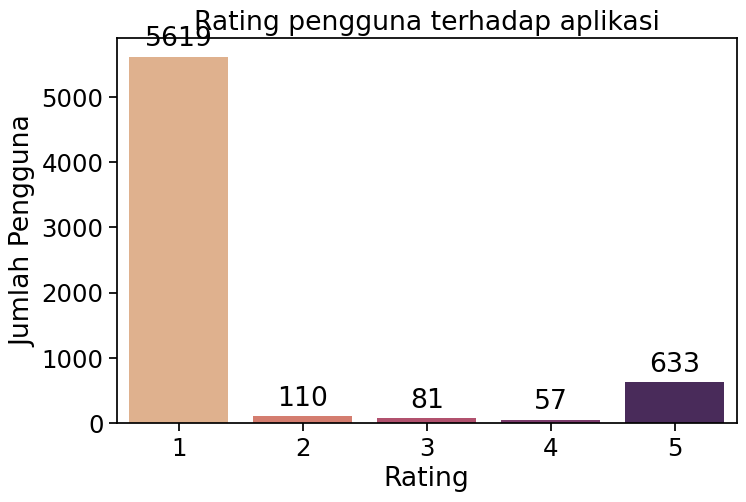

In [958]:
rating = df_2026.groupby('score')['userName'].count().reset_index(name='jumlah')
plt.figure(figsize=(8, 5))

fig = sns.barplot( x='score',
    y='jumlah',
    data=rating,
    hue='score',
    palette='flare',
    legend=False
)
for i in fig.containers:
    fig.bar_label(i, padding = 3)

plt.xlabel('Rating')
plt.ylabel('Jumlah Pengguna')
plt.title('Rating pengguna terhadap aplikasi')



Berdasarkan grafik, mayoritas pengguna memberikan rating 1 dengan jumlah 5.619 pengguna. Sementara itu, rating 5 diberikan oleh 633 pengguna, diikuti rating 2 sebanyak 110 pengguna, rating 3 sebanyak 81 pengguna, dan rating 4 sebanyak 57 pengguna. Hal ini menunjukkan bahwa pada periode data yang dianalisis, rating pengguna sangat didominasi oleh rating 1

In [959]:
# Pastikan kolom tanggal sudah datetime
df['at'] = pd.to_datetime(df['at'], errors='coerce')

# Ambil hanya rating 1
rating_1 = df[df['score'] == 1].copy()

# Hitung jumlah rating 1 per tanggal
rating_1_per_date = (
    rating_1
    .groupby(rating_1['at'].dt.date)
    .size()
    .reset_index(name='jumlah_rating_1')
)

# Urutkan dari jumlah terbanyak
rating_1_per_date = rating_1_per_date.sort_values(
    'jumlah_rating_1',
    ascending=False
)

# Tampilkan tanggal dengan rating 1 terbanyak
print(rating_1_per_date.head(10))

            at  jumlah_rating_1
0   2026-08-25             3221
1   2026-08-26             1219
2   2026-08-27              377
3   2026-08-28              124
4   2026-08-29               79
5   2026-08-30               74
7   2026-09-01               56
21  2026-09-15               46
6   2026-08-31               45
10  2026-09-04               42


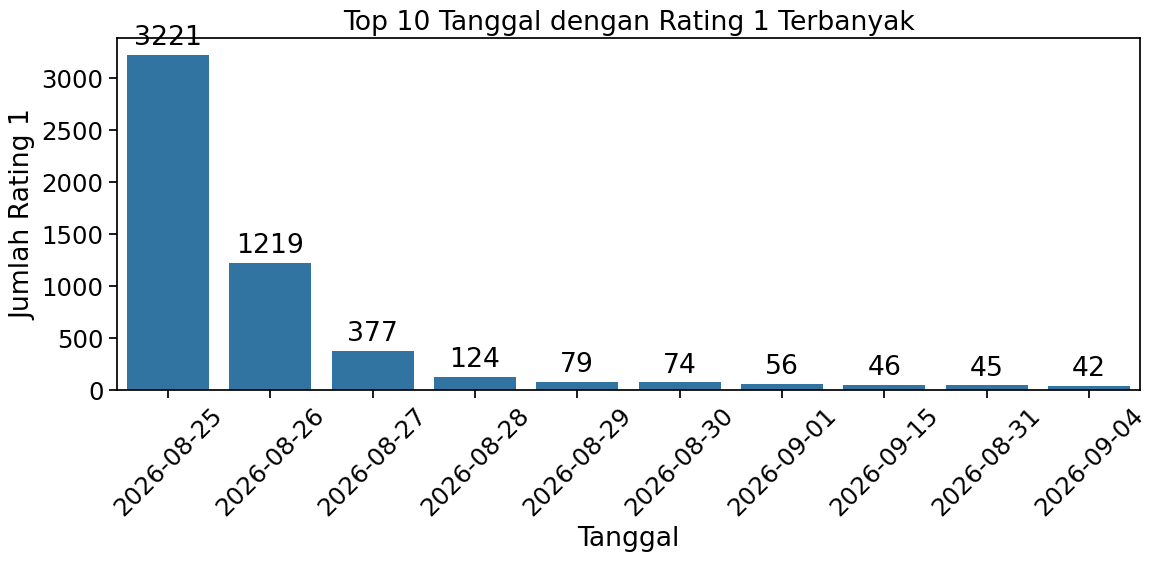

In [960]:
top_10 = rating_1_per_date.head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10,
    x='at',
    y='jumlah_rating_1'
)

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.title('Top 10 Tanggal dengan Rating 1 Terbanyak')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Rating 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa rating 1 paling banyak diberikan pada 25 Agustus 2026, dengan total 3.221 rating. Jumlah ini jauh lebih tinggi dibandingkan tanggal berikutnya, yaitu 26 Agustus 2026 dengan 1.219 rating.

Setelah itu, jumlah rating 1 turun cukup tajam:

27 Agustus: 377
28 Agustus: 124
29 Agustus: 79
30 Agustus: 74

Menariknya, 25–27 Agustus 2026 menjadi periode dengan konsentrasi rating 1 tertinggi. Periode ini berdekatan dengan ramainya seruan boikot Bank Mandiri pada 25 Agustus, sehingga pola tersebut dapat digunakan sebagai indikasi adanya perubahan respons pengguna pada periode isu.

# Cleaning

### a.Mengganti emoji menjadi kata

In [961]:
emoji_df = pd.read_csv(
    'emoji.csv',
    encoding='utf-8-sig'
)

emoji_dict = dict(
    zip(
        emoji_df['emoji'],
        emoji_df['translation']
    )
)

In [962]:
def replace_emoji(text):
    for emoji, translation in emoji_dict.items():
        text = text.replace(emoji, f' {translation} ')
    return text

In [963]:
df['emoji_clean'] = df['content'].apply(lambda x: replace_emoji(x))

In [964]:
df[['content', 'emoji_clean']].head(5)

,content,emoji_clean
0,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the Best aplikasi for internet banking
2,lemot,lemot
3,sangat baik,sangat baik
4,tampilan menarik. mudah di pakai,tampilan menarik. mudah di pakai


### b. Menghapus unsur kata yang tidak perlu

In [965]:
def text_cleaning(text):
    text = text.lower()
    text = text.replace('..', ' ')
    text = text.replace('...', ' ')
    text = text.replace('....', ' ')
    text = text.encode('ascii', 'replace').decode('ascii') # remove non ASCII (emoticon, chinese word, .etc)
    text = text.replace(r'\d+', "") # remove digits
    text = text.translate(str.maketrans("","",string.punctuation)) #remove punctuation
    text = text.strip() # remove whitespace from the beginning and end
    text = re.sub(r'\s+',' ', text) # remove multiple whitespace

    return text

In [966]:
df['text_clean'] = df['emoji_clean'].apply(lambda x: text_cleaning(x))

In [967]:
df[['content','emoji_clean','text_clean']].head(10)

,content,emoji_clean,text_clean
0,berguna,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot
3,sangat baik,sangat baik,sangat baik
4,tampilan menarik. mudah di pakai,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai
5,mantap,mantap,mantap
6,okeh,okeh,okeh
7,asal mau logi hp selalu mati,asal mau logi hp selalu mati,asal mau logi hp selalu mati
8,Penarikan tunai gampang dan TF juga sangat gampang,Penarikan tunai gampang dan TF juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang
9,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga


### c. Mengganti kesalahan penulisan (typo)

In [968]:
normalisasi =pd.read_csv('normalisasi.csv')

In [969]:
slang_dict = dict(zip(normalisasi['before'], normalisasi['after']))

In [970]:
def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return ' '.join(words)

In [971]:
df['Normalisasi'] = df['text_clean'].apply(normalize_slang)

In [972]:
df[['content','emoji_clean','text_clean', 'Normalisasi']].head(5)

,content,emoji_clean,text_clean,Normalisasi
0,berguna,berguna,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot,lambat
3,sangat baik,sangat baik,sangat baik,sangat baik
4,tampilan menarik. mudah di pakai,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai


### d. load kamus stopwords menggunakan tala

In [973]:
# load kamus stopwords menggunakan tala

tala = pd.read_csv('StopWords_Tala.csv')

In [974]:

stopwords_tala = set(tala['LEMA'])


In [975]:

# membuat function untuk mengaplikasikan kamus tala ke dalam data teks
def remove_stopwords(text):
    return ' '.join([i for i in text if i not in stopwords_tala])

In [976]:
df['tweet_tala'] = df['Normalisasi'].apply(lambda x: remove_stopwords(x.split()))
df[['content','emoji_clean','text_clean', 'Normalisasi','tweet_tala']].head(5
                                                              )

,content,emoji_clean,text_clean,Normalisasi,tweet_tala
0,berguna,berguna,berguna,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot,lambat,lambat
3,sangat baik,sangat baik,sangat baik,sangat baik,baik
4,tampilan menarik. mudah di pakai,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah pakai


### e. Ubah kata berimbuan menggunakan sastrawi(Steamer)

In [977]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem(text):
    """
    :param text:
    :return: stemmed text
    """
    return stemmer.stem(text)

In [978]:

df['tweet_stem_tala'] = df['tweet_tala'].apply(lambda x: stem(x))

In [979]:
df[['content','emoji_clean','text_clean', 'Normalisasi','tweet_tala','tweet_stem_tala']].head(5
                                                              )

,content,emoji_clean,text_clean,Normalisasi,tweet_tala,tweet_stem_tala
0,berguna,berguna,berguna,berguna,berguna,guna
1,one of the Best aplikasi for internet banking,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot,lambat,lambat,lambat
3,sangat baik,sangat baik,sangat baik,sangat baik,baik,baik
4,tampilan menarik. mudah di pakai,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah pakai,tampil tarik mudah pakai


# Klasifikasi berdasarkan rating

In [980]:
def rating_to_sentiment(score):
    if score <= 3:
        return 'Negative'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(rating_to_sentiment)

Klasifikasi sentiment berdasarkan rating dilakukan dengan mengubah rating pengguna menjadi dua kategori sentiment. Rating 1–3 dikategorikan sebagai Negative, sedangkan rating 4–5 dikategorikan sebagai Positive. Label ini digunakan sebagai acuan untuk mengevaluasi hasil klasifikasi sentiment berbasis teks.

# Train Test

In [981]:
X = df['Normalisasi']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TFIDF

In [982]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

TF-IDF digunakan untuk mengubah teks review menjadi representasi numerik berdasarkan tingkat kepentingan setiap kata dalam dataset. Representasi ini kemudian digunakan sebagai input untuk model Logistic Regression dalam melakukan klasifikasi sentiment

# Menggunakan Logistic Regression

In [983]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(
    classification_report(
        y_test,
        lr_pred,
        digits=3
    )
)

Accuracy: 0.93
              precision    recall  f1-score   support

    Negative      0.967     0.954     0.961      1162
    Positive      0.654     0.725     0.687       138

    accuracy                          0.930      1300
   macro avg      0.810     0.840     0.824      1300
weighted avg      0.934     0.930     0.932      1300



In [984]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    
    "Naive Bayes": MultinomialNB(),
    
    "Linear SVM": LinearSVC(
        class_weight='balanced',
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = []

for name, model in models.items():
    
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred)
    })
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(
        y_test,
        pred,
        digits=3
    ))

Logistic Regression
              precision    recall  f1-score   support

    Negative      0.967     0.954     0.961      1162
    Positive      0.654     0.725     0.687       138

    accuracy                          0.930      1300
   macro avg      0.810     0.840     0.824      1300
weighted avg      0.934     0.930     0.932      1300

Naive Bayes
              precision    recall  f1-score   support

    Negative      0.935     0.997     0.965      1162
    Positive      0.950     0.413     0.576       138

    accuracy                          0.935      1300
   macro avg      0.942     0.705     0.770      1300
weighted avg      0.936     0.935     0.924      1300

Linear SVM
              precision    recall  f1-score   support

    Negative      0.959     0.965     0.962      1162
    Positive      0.687     0.652     0.669       138

    accuracy                          0.932      1300
   macro avg      0.823     0.808     0.815      1300
weighted avg      0.930     0.9

Dengan pertimbangan nilai f1 terbaik pada prediksi poitif maka kami mengambil Logistic Regression.Model Logistic Regression memperoleh accuracy sebesar 93%. Performa pada kelas Negative cukup tinggi dengan F1-score 96.1%, sedangkan kelas Positive memiliki F1-score 68.7%. Perbedaan performa tersebut berkaitan dengan ketidakseimbangan kelas, karena data Negative jauh lebih banyak dibandingkan Positive.

In [985]:
# Probabilitas Positive
y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Coba threshold 0.6
lr_pred_threshold = np.where(
    y_prob >= 0.6,
    'Positive',
    'Negative'
)


print("Threshold 0.6")
print(classification_report(
    y_test,
    lr_pred_threshold,
    digits=3
))

Threshold 0.6
              precision    recall  f1-score   support

    Negative      0.959     0.967     0.963      1162
    Positive      0.703     0.652     0.677       138

    accuracy                          0.934      1300
   macro avg      0.831     0.810     0.820      1300
weighted avg      0.932     0.934     0.933      1300



Threshold 0.6 dipilih untuk meningkatkan precision pada kelas Positive. Dengan menaikkan threshold dari default ke 0.6, precision Positive meningkat dari 65.4% menjadi 70.3%. Artinya, prediksi Positive menjadi lebih selektif dan proporsi prediksi Positive yang benar meningkat. Namun, terdapat trade-off berupa penurunan recall Positive dari 72.5% menjadi 65.2%, sehingga sebagian review Positive tidak berhasil teridentifikasi.

In [986]:
X_all_tfidf = tfidf.transform(df['Normalisasi'])

y_prob_all = lr_model.predict_proba(X_all_tfidf)[:, 1]

df['ml_sentiment'] = np.where(
    y_prob_all >= 0.6,
    'Positive',
    'Negative'
)

positive_words = r'\b(cool|best|excellence|helpful)\b'

positive_mask = df['Normalisasi'].str.lower().str.contains(
    positive_words,
    regex=True,
    na=False
)

df.loc[positive_mask, 'ml_sentiment'] = 'Positive'
# Tambahan aturan kata positif


C:\Users\cacab\AppData\Local\Temp\ipykernel_4736\3421416959.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  positive_mask = df['Normalisasi'].str.lower().str.contains(


In [987]:
pd.crosstab(
    df['sentiment'],
    df['ml_sentiment']
)

ml_sentiment,Negative,Positive
sentiment,,
Negative,5702,108
Positive,90,600


Dari 6.500 review, sebanyak 6.302 review (96,95%) memiliki hasil sentiment yang sesuai antara label berdasarkan rating dan prediksi model, sedangkan 198 review (3,05%) menunjukkan ketidaksesuaian.

In [988]:
df['sesuai'] = df['sentiment'] == df['ml_sentiment']

df['hasil'] = df['sesuai'].map({
    True: 'Sesuai',
    False: 'Tidak Sesuai'
})

In [989]:
df['hasil'].value_counts()

hasil
Sesuai          6302
Tidak Sesuai     198
Name: count, dtype: int64

In [990]:
df['hasil'].value_counts(normalize=True) * 100

hasil
Sesuai         96.95
Tidak Sesuai    3.05
Name: proportion, dtype: float64

### Analisis Hasil Klasifikasi

Berdasarkan hasil klasifikasi, terdapat 6.302 data (96,95%) yang termasuk kategori Sesuai, sedangkan 198 data (3,05%) termasuk kategori Tidak Sesuai.

Dari 198 data yang tidak sesuai, dilakukan pengecekan terhadap isi review untuk memahami penyebab perbedaan antara sentiment berdasarkan rating dan hasil prediksi model. Hasil pengecekan menunjukkan bahwa lebih dari 40% data yang tidak sesuai memiliki karakteristik khusus pada isi review, seperti penggunaan sarkasme atau adanya kritik yang disampaikan bersamaan dengan rating rendah.

Beberapa kondisi yang ditemukan antara lain:

Sarkasme: Terdapat review yang menggunakan sarkasme sehingga makna teks secara literal berbeda dengan maksud sebenarnya. Kondisi ini dapat menjadi tantangan bagi model dalam mengidentifikasi sentiment berdasarkan teks.
Kritik dengan rating rendah: Ditemukan review yang memiliki rating rendah dan berisi kritik terhadap aplikasi. Pada kondisi ini, sentiment berdasarkan teks dan rating sebenarnya dapat sama-sama menunjukkan pengalaman negatif, tetapi terdapat perbedaan pada hasil klasifikasi model. 



In [991]:
#df.to_csv("Hasil_ML9.csv", index=False)

#print("CSV berhasil dibuat!")
#print(df.head())

In [992]:
df_Neg = df[(df['ml_sentiment']=="Negative")]


In [993]:
df_Neg.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,emoji_clean,text_clean,Normalisasi,tweet_tala,tweet_stem_tala,sentiment,ml_sentiment,sesuai,hasil
2,033bdc94-59da-4558-8821-8bd2256669ea,Dimas Dipta,https://play-lh.googleusercontent.com/a/ACg8ocK7vvXX2NoVRGmX45z9oRN0t64v1FQXwnJsNO3ZvvzZyLU3NQ=mo,lemot,3,0,3.7.0,2026-09-15 19:31:29,"Halo Sahabat @Dimas Dipta, mohon maaf atas ketidaknyamanannya. Terkait kendala Sahabat mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi Mandiri Call 14000 agar dapat dilakukan pengecekan. Tks~Feri",2026-09-15 19:33:49,3.7.0,lemot,lemot,lambat,lambat,lambat,Negative,Negative,True,Sesuai
7,54405d9b-626a-4e10-aa42-3ed33bb6d46c,putra 6,https://play-lh.googleusercontent.com/a/ACg8ocIuyBnGYEh3gizO5ft0c71QSr7JzBRfkxYcz76p4r0H1gj02Q=mo,asal mau logi hp selalu mati,5,0,3.8.0,2026-09-15 19:16:06,"Halo Sahabat @putra 6, mohon maaf atas ketidanyamanannya. Terkait kendala Sahabat mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi mandiri call 14000 agar dapkat dilakukan pengecekan. Tks~Kale",2026-09-15 19:17:28,3.8.0,asal mau logi hp selalu mati,asal mau logi hp selalu mati,asal mau login hp selalu mati,login hp mati,login hp mati,Positive,Negative,False,Tidak Sesuai
11,5e275435-b2dc-4d76-94e0-942db26a9150,Sindi Gea,https://play-lh.googleusercontent.com/a/ACg8ocIW-iy3QSCAJ-moWzJ58APhQOtgiRkvFxl4fcwUU_PkmbFznA=mo,"kenapa hari² harus update padahal ga sering² di buka, bahkan juga ga di apa²in tapi tetap aja setelah di update gada tu fitur terbaru, tolong di perbaiki dong",3,0,NaN,2026-09-15 19:02:43,"Halo Sahabat @Sindi Gea, mohon maaf atas ketidanyamanannya. Terkait kendala Sahabat mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi mandiri call 14000 agar dapkat dilakukan pengecekan. Tks~Kale",2026-09-15 19:05:02,NaN,"kenapa hari² harus update padahal ga sering² di buka, bahkan juga ga di apa²in tapi tetap aja setelah di update gada tu fitur terbaru, tolong di perbaiki dong",kenapa hari harus update padahal ga sering di buka bahkan juga ga di apain tapi tetap aja setelah di update gada tu fitur terbaru tolong di perbaiki dong,kenapa hari harus perbarui padahal tidak sering di buka bahkan juga tidak di apain tetapi tetap aja setelah di perbarui gaada tu fitur terbaru tolong di perbaiki dong,perbarui buka apain perbarui gaada tu fitur terbaru perbaiki,baru buka apain baru gaada tu fitur baru baik,Negative,Negative,True,Sesuai
12,e29e2b0d-1225-4042-ba3e-925806ea300b,Genta Putra Dua,https://play-lh.googleusercontent.com/a/ACg8ocJMDRIPenYyiuOcnzJNmLA76z4m5v9n76l7CMnXIYP_dWcaqoU=mo,"ribet banget kalo urus kartu hilang, harus nunggu 2 minggu ditelp cabang pusat, cabang pembuatan",1,0,3.8.0,2026-09-15 18:59:25,"Halo Sahabat @Genta Putra Dua, mohon maaf atas ketidaknyamanannya. Terkait kendala Sahabat, mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi mandiri call 14000 agar dapat dilakukan pengecekan. Tks~Vika",2026-09-15 19:02:14,3.8.0,"ribet banget kalo urus kartu hilang, harus nunggu 2 minggu ditelp cabang pusat, cabang pembuatan",ribet banget kalo urus kartu hilang harus nunggu 2 minggu ditelp cabang pusat cabang pembuatan,ribet banget kalau urus kartu hilang harus nunggu 2 minggu ditelp cabang pusat cabang pembuatan,ribet urus kartu hilang nunggu 2 minggu ditelp cabang pusat cabang pembuatan,ribet urus kartu hilang nunggu 2 minggu ditelp cabang pusat cabang buat,Negative,Negative,True,Sesuai
16,8e929ddc-e2cd-4002-b01b-e725be73afbe,Fernando Koneng,https://play-lh.googleusercontent.com/a/ACg8ocJt1RCC0wmu9wSL-7eduScsln24d1cLcogB_BE4c6cSa5sNQA=mo,pihak mandiri sngat bodoh yang dilindungi bukan kenyamanan konsumen.. ini seringkali kami harus mengurus untuk membuka bloked ke pihak manfiri langsung.. padahal transaksi yg kami lakukan itu tidak seharusnya di campur tangan pihak bank.. ini bangat 

In [994]:
df_Pos = df_2026[(df_2026['ml_sentiment']=="Positive")]

### Tidak ingin berfokus pada kata hubung atau domain seperti nama bank

In [995]:
stopwords_en = {
    'aplikasi', 'app', 'apps',
    'livin', 'mandiri', 'bank',
    'g', 'k', 's', 'x', 'e',
    'nih', 'tuh', 'deh', 'sih','ga','gak','no','not','tp','tdk','dah','that','bgt', 'ama',
    'ah',
    'bikin',
    'coba',
    'gitu',
    'kasih',
    'mas',
    'gue',
    'gw',
    'tau',
    
    
    'the', 'to', 'i', 'it', 'and', 'is', 'in',
    'my', 'this', 'for', 'a', 'an', 'of',
    'on', 'with', 'by', 'you', 'your', 'me',
    'up', 'out', 'at', 'from', 'or', 'but',
    'very', 'just', 'all', 'more', 'most',
    'when', 'what', 'why', 'how',
    'have', 'has', 'been', 'was', 'are',
    'be', 'do', 'does', 'did','the','lot','even','gk','bs','bgt','its','bs','udah'
}


In [996]:
def remove_stopwords(text):
    return ' '.join(
        word for word in text.split()
        if word not in stopwords_en
    )

## Membagi sentiment positif dan negatif

In [997]:
df_Neg['text_no_stopword'] = df_Neg['tweet_stem_tala'].apply(remove_stopwords)

C:\Users\cacab\AppData\Local\Temp\ipykernel_4736\1193599246.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Neg['text_no_stopword'] = df_Neg['tweet_stem_tala'].apply(remove_stopwords)


In [998]:
df_Pos['text_no_stopword'] = df_Pos['tweet_stem_tala'].apply(remove_stopwords)

C:\Users\cacab\AppData\Local\Temp\ipykernel_4736\1333787869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Pos['text_no_stopword'] = df_Pos['tweet_stem_tala'].apply(remove_stopwords)


In [999]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [1000]:
kamus_clean_neg = kamus(df_Neg['text_no_stopword'])
kamus_clean_Pos = kamus(df_Pos['text_no_stopword'])

# Hasil 

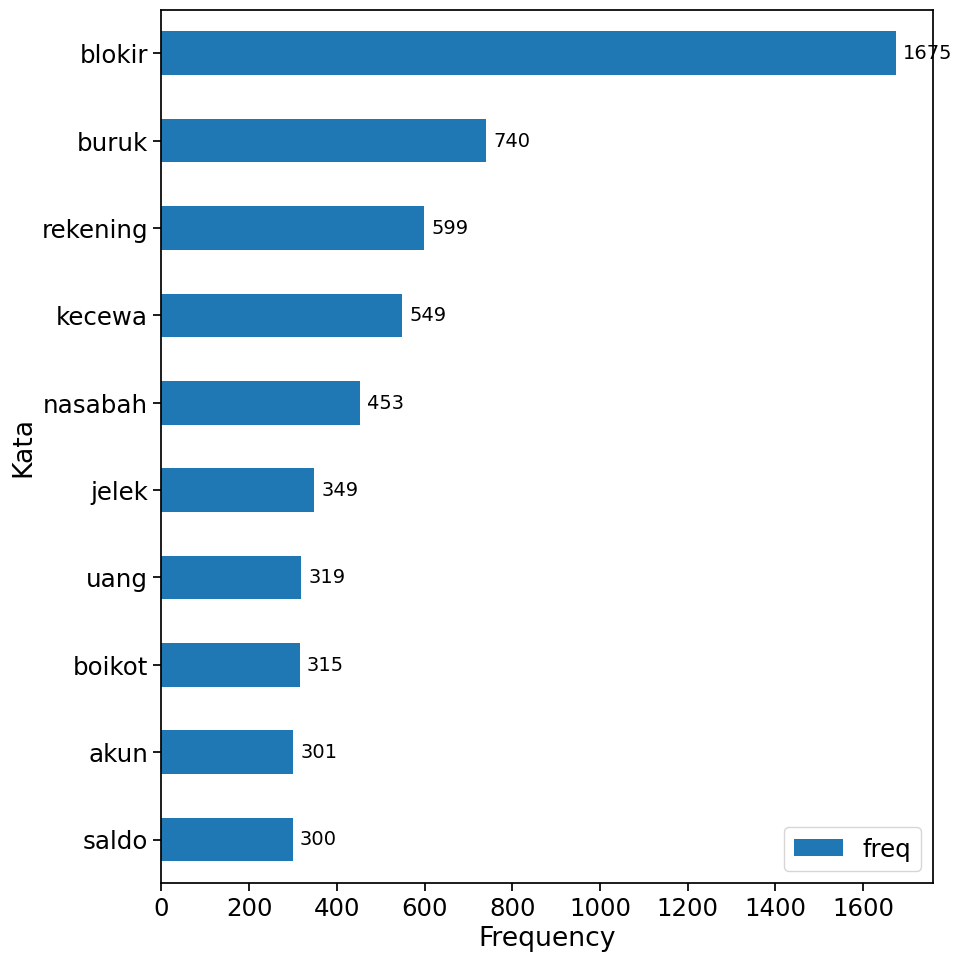

In [1001]:

sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_neg[:10].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

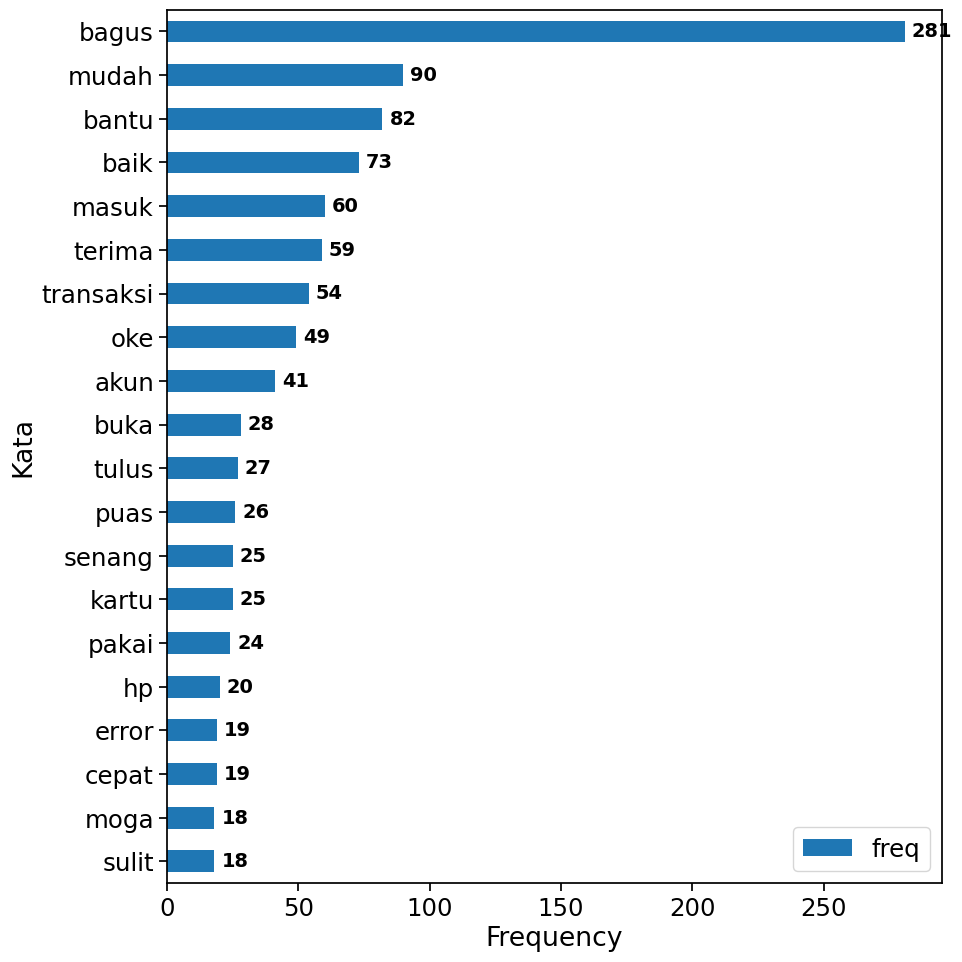

In [1002]:
sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_Pos[:20].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

In [1003]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

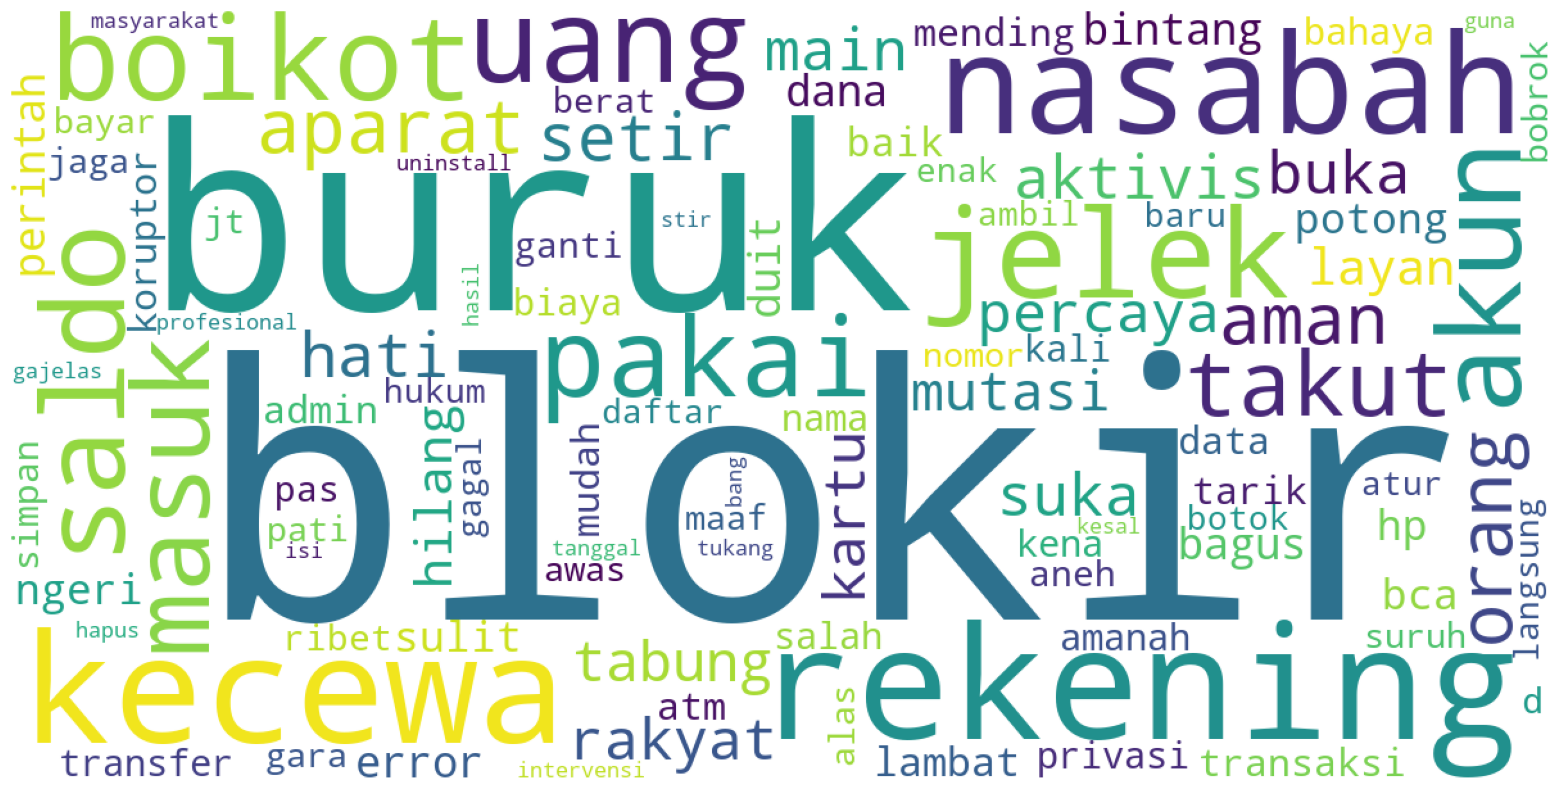

In [1004]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil = kamus_clean_neg.head(150)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil['freq'].to_dict()

word_cloud_neg = WordCloud(
    background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_neg)


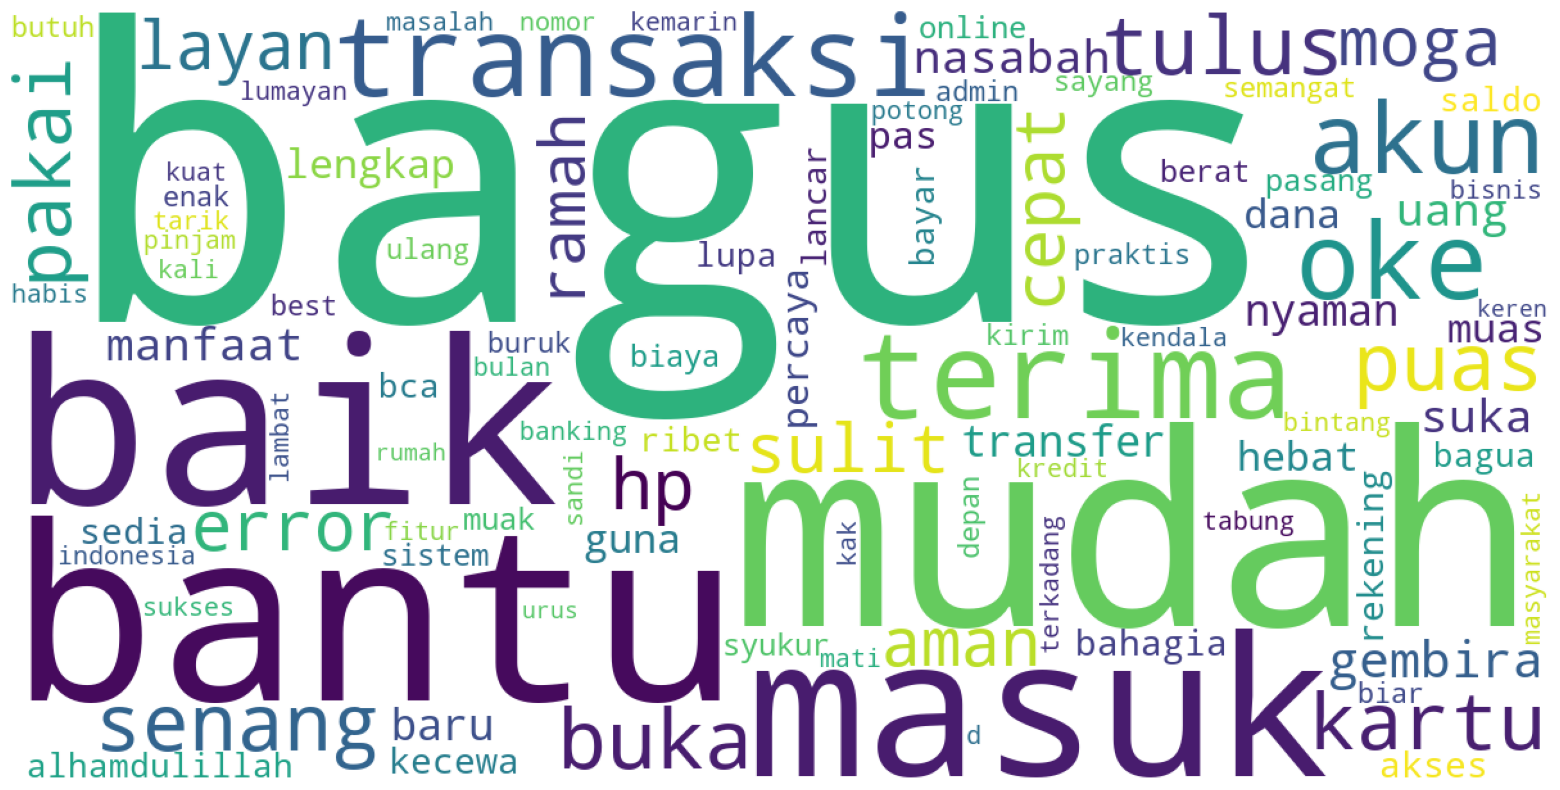

In [1005]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil2 = kamus_clean_Pos.head(100)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil2['freq'].to_dict()

word_cloud_pos = WordCloud(
      background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_pos)

1. Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan?

Berdasarkan hasil analisis sentiment, persepsi pengguna terhadap Livin' by Mandiri terbagi menjadi sentimen Positive dan Negative.

Pada ulasan Positive, kata yang dominan seperti mudah, bagus, bantu, aman, transaksi, bayar, senang, puas, cepat, dan lancar menunjukkan bahwa pengguna mengapresiasi kemudahan penggunaan, kelancaran transaksi, keamanan, serta fungsi perbankan dalam aplikasi.

Sementara itu, pada ulasan Negative, terdapat dua konteks utama. Pertama, keluhan terkait penggunaan aplikasi, yang ditunjukkan oleh kata seperti error, login, transaksi, bayar, kartu, sulit, ribet, dan lambat. Kedua, terdapat respons pengguna terhadap isu A, yang terlihat dari kata seperti boikot, aparat, rekening, blokir, pemerintah, dan aktivis.

Dengan demikian, persepsi pengguna tidak hanya dipengaruhi oleh pengalaman menggunakan aplikasi, tetapi juga oleh isu eksternal yang muncul pada periode pengumpulan data.

2. Apakah terdapat perubahan sentimen pelanggan setelah isu A?

Hasil analisis menunjukkan bahwa isu A muncul dalam sejumlah ulasan Negative, terutama melalui kata boikot, aparat, rekening, blokir, pemerintah, dan aktivis.

Selain itu, distribusi rating menunjukkan lonjakan rating 1 pada 25 Agustus 2026 sebanyak 3.221 rating, kemudian menurun menjadi 1.219 pada 26 Agustus dan 377 pada 27 Agustus. Periode tersebut berdekatan dengan periode ramainya respons terhadap isu A.

Hal ini menunjukkan adanya perubahan pola respons pengguna pada periode tersebut. Namun, lonjakan rating 1 tidak dapat secara langsung dianggap sebagai akibat dari isu A karena rating juga dapat dipengaruhi oleh pengalaman pengguna terhadap aplikasi. Oleh karena itu, isi review dan konteks kata-kata terkait isu perlu dianalisis bersama untuk memahami perubahan tersebut.

3. Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?

Berdasarkan WordCloud Positive, aspek yang paling banyak mendapatkan respons positif adalah:

Kemudahan penggunaan → mudah, gampang, praktis
Transaksi → transaksi, bayar, transfer, tarik
Keamanan dan kepercayaan → aman, percaya
Kecepatan dan kelancaran → cepat, lancar
Kepuasan pengguna → bagus, senang, puas, suka, oke

Hal tersebut menunjukkan bahwa kemudahan, keamanan, kelancaran transaksi, dan fungsi utama perbankan merupakan aspek yang diapresiasi pengguna dan dapat dipertahankan.

4. Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?

Berdasarkan WordCloud Negative, keluhan terkait aplikasi terutama berkaitan dengan akses dan penggunaan layanan, seperti login, error, transaksi, bayar, kartu, sulit, ribet, dan lambat.

Di sisi lain, terdapat kata boikot, aparat, rekening, blokir, dan pemerintah yang lebih berkaitan dengan respons terhadap isu A, sehingga perlu dipisahkan dari keluhan teknis aplikasi.

Dengan demikian, dari sisi produk, area yang dapat menjadi perhatian adalah stabilitas aplikasi, proses login dan akses, transaksi, pembayaran, serta kemudahan penggunaan. Sementara itu, kata-kata terkait isu A dapat digunakan untuk memahami faktor eksternal yang turut membentuk sentimen pengguna selama periode analisis.